In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries berhasil di-import!")

✅ Libraries berhasil di-import!


In [ ]:
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')
sub   = pd.read_csv('/content/sample_submission.csv')

print(f"✅ Data dimuat: Train {train.shape} | Test {test.shape}")
print("\nPreview data:")
print(train.head(3))
print("\nInfo kolom:")
print(train.info())

✅ Data dimuat: Train (8693, 14) | Test (4277, 13)

Preview data:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck             Name  \
0          0.0        0.0           0.0     0.0     0.0  Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0     Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0    Altark Susent   

   Transported  
0        False  
1         True  
2        False  

Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-

In [15]:
def feature_engineering(df):
    df = df.copy()

    # --- 3a. Pecah kolom 'Cabin' menjadi Deck, Num, Side ---
    # Format Cabin: "B/0/P" -> Deck=B, Num=0, Side=P
    # Informasi posisi di kapal bisa sangat prediktif!
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Num'] = pd.to_numeric(df['Num'], errors='coerce')
    df.drop(columns=['Cabin'], inplace=True)

    # --- 3b. Buat kolom 'TotalSpending' ---
    # Penumpang yang banyak belanja mungkin punya pola survival berbeda.
    # Daripada model harus belajar sendiri dari 5 kolom terpisah,
    # kita bantu dengan fitur agregat ini.
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpending'] = df[spending_cols].sum(axis=1)

    # --- 3c. Buat kolom 'IsSolo' ---
    # PassengerId format: "0001_01" -> grup "0001", orang ke-"01"
    # Jika hanya ada 1 orang dalam grup, berarti dia bepergian sendiri.
    df['GroupId']    = df['PassengerId'].str.split('_').str[0]
    df['GroupSize']  = df.groupby('GroupId')['GroupId'].transform('count')
    df['IsSolo']     = (df['GroupSize'] == 1).astype(int)
    df.drop(columns=['GroupId', 'GroupSize'], inplace=True)

    # Hapus kolom yang tidak berguna untuk model
    df.drop(columns=['PassengerId', 'Name'], inplace=True)

    return df

train = feature_engineering(train)
test  = feature_engineering(test)

print("✅ Feature engineering selesai!")
print(f"Kolom setelah FE: {list(train.columns)}")

✅ Feature engineering selesai!
Kolom setelah FE: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Deck', 'Num', 'Side', 'TotalSpending', 'IsSolo']


In [ ]:
def fill_missing(df_train, df_test):
    df_train = df_train.copy()
    df_test  = df_test.copy()

    num_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = df_train.select_dtypes(include=['object', 'bool']).columns

    # Hitung median/modus dari data TRAIN, lalu apply ke test
    # (hindari data leakage dari test set!)
    for col in num_cols:
        median_val = df_train[col].median()
        df_train[col].fillna(median_val, inplace=True)
        df_test[col].fillna(median_val, inplace=True)

    for col in cat_cols:
        mode_val = df_train[col].mode()[0]
        df_train[col].fillna(mode_val, inplace=True)
        df_test[col].fillna(mode_val, inplace=True)

    return df_train, df_test

X = train.drop('Transported', axis=1)
y = train['Transported']

X, test = fill_missing(X, test)

print("✅ Missing values berhasil ditangani!")
print(f"Sisa NaN di X: {X.isnull().sum().sum()}")
print(f"Sisa NaN di test: {test.isnull().sum().sum()}")

✅ Missing values berhasil ditangani!
Sisa NaN di X: 0
Sisa NaN di test: 0


In [17]:
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"\nKolom kategorikal: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    # Gabungkan train & test untuk LabelEncoder agar semua nilai dikenali
    combined = pd.concat([X[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    X[col]    = le.transform(X[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

print("✅ Label Encoding selesai!")
print(X.dtypes)


Kolom kategorikal: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
✅ Label Encoding selesai!
HomePlanet         int64
CryoSleep          int64
Destination        int64
Age              float64
VIP                int64
RoomService      float64
FoodCourt        float64
ShoppingMall     float64
Spa              float64
VRDeck           float64
Deck               int64
Num              float64
Side               int64
TotalSpending    float64
IsSolo             int64
dtype: object


In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # pastikan proporsi kelas seimbang di train & val
)

print(f"✅ Split selesai: Train={X_train.shape} | Val={X_val.shape}")

✅ Split selesai: Train=(6954, 15) | Val=(1739, 15)


In [19]:
model = XGBClassifier(
    n_estimators    = 500,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = 42,
    use_label_encoder = False,
    eval_metric     = 'logloss',
    early_stopping_rounds = 30  # berhenti jika val tidak membaik 30 ronde
)

# early_stopping_rounds = otomatis berhenti training jika tidak ada peningkatan
# ini mencegah overfitting (mirip EarlyStopping callback di Keras/ANN)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50  # print progress tiap 50 ronde
)

print("\n✅ Model selesai ditraining!")

[0]	validation_0-logloss:0.67450
[50]	validation_0-logloss:0.40475
[100]	validation_0-logloss:0.37656
[150]	validation_0-logloss:0.36993
[200]	validation_0-logloss:0.36657
[235]	validation_0-logloss:0.36693

✅ Model selesai ditraining!


In [20]:
y_pred = model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print(f"\n🎯 Validation Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Not Transported', 'Transported']))


🎯 Validation Accuracy: 0.8114 (81.14%)

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.81      0.81      0.81       863
    Transported       0.81      0.82      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



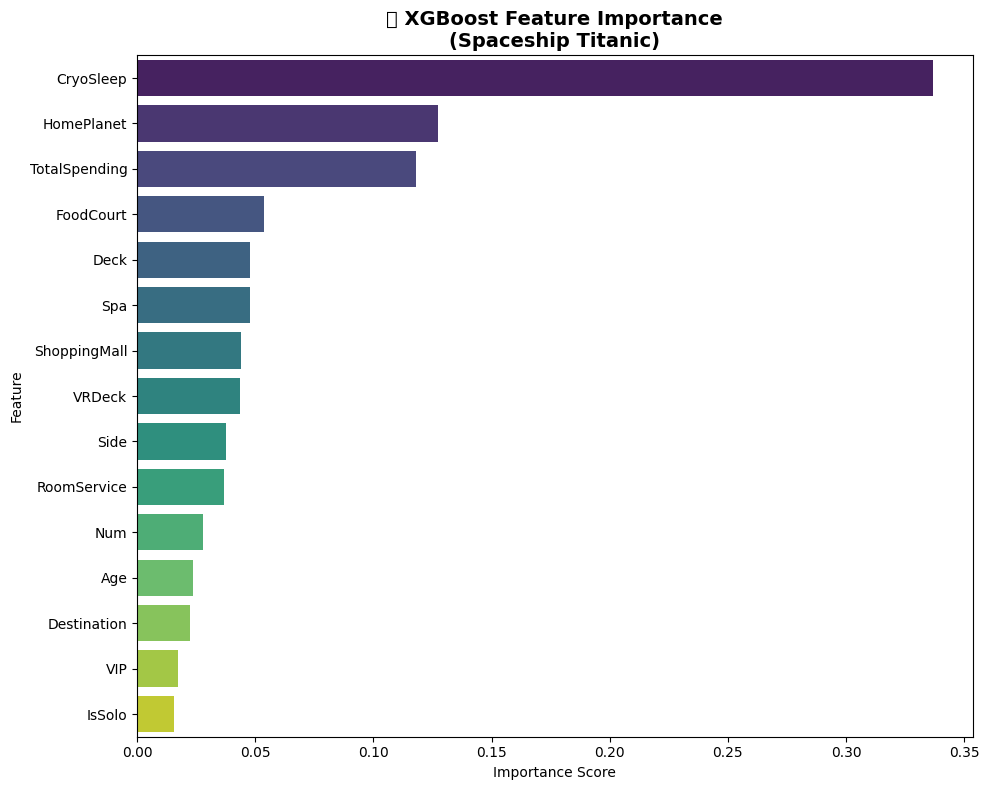

✅ Grafik Feature Importance tersimpan!

Top 5 Fitur Paling Berpengaruh:
      Feature  Importance
    CryoSleep    0.336731
   HomePlanet    0.127268
TotalSpending    0.118089
    FoodCourt    0.053549
         Deck    0.047877


In [ ]:
importance_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('XGBoost Feature Importance\n(Spaceship Titanic)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik Feature Importance tersimpan!")

print("\nTop 5 Fitur Paling Berpengaruh:")
print(importance_df.head(5).to_string(index=False))

In [23]:
test_ids   = sub['PassengerId']
y_test_pred = model.predict(test)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': y_test_pred.astype(bool)  # Kaggle butuh True/False
})

submission.to_csv('submission.csv', index=False)
print("\n✅ File 'submission.csv' berhasil dibuat!")
print(submission.head(10))
print(f"\nDistribusi prediksi:\n{submission['Transported'].value_counts()}")

print("\n🚀 Pipeline selesai! Cek file 'submission.csv' untuk di-upload ke Kaggle.")


✅ File 'submission.csv' berhasil dibuat!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
5     0027_01         True
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01        False

Distribusi prediksi:
Transported
True     2165
False    2112
Name: count, dtype: int64

🚀 Pipeline selesai! Cek file 'submission.csv' untuk di-upload ke Kaggle.
